# Object Localization with TensorFlow

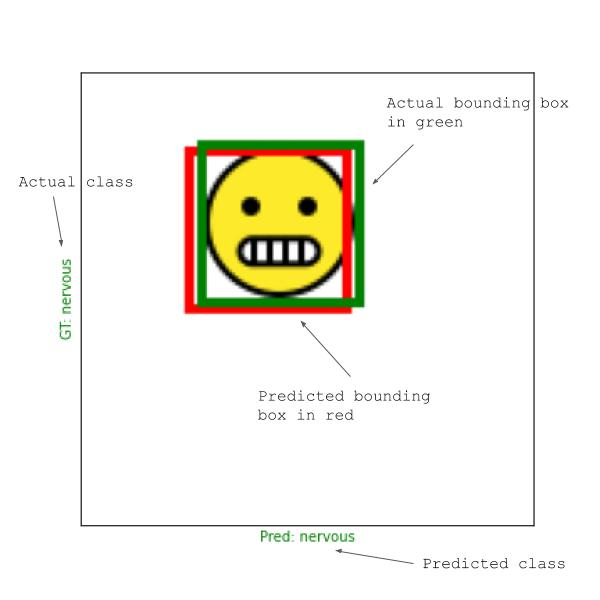

All emojis designed by [OpenMoji](https://openmoji.org/) – the open-source emoji and icon project. License: CC BY-SA 4.0

## Task 1: Download and Visualize Data

In [1]:
!wget https://github.com/hfg-gmuend/openmoji/releases/latest/download/openmoji-72x72-color.zip
!mkdir emojis
!unzip -q openmoji-72x72-color.zip -d ./emojis

--2026-03-23 18:11:17--  https://github.com/hfg-gmuend/openmoji/releases/latest/download/openmoji-72x72-color.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/hfg-gmuend/openmoji/releases/download/16.0.0/openmoji-72x72-color.zip [following]
--2026-03-23 18:11:18--  https://github.com/hfg-gmuend/openmoji/releases/download/16.0.0/openmoji-72x72-color.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/114106318/9532d5d3-3294-49ab-b7f9-5da918081758?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-23T19%3A00%3A12Z&rscd=attachment%3B+filename%3Dopenmoji-72x72-color.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-23T17%3A59%3A

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from PIL import Image, ImageDraw
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPool2D, BatchNormalization, Dropout

print('Check if we are using latest version of TensorFlow.')
print('Using TensorFlow version', tf.__version__)

Check if we are using latest version of TensorFlow.
Using TensorFlow version 2.19.0


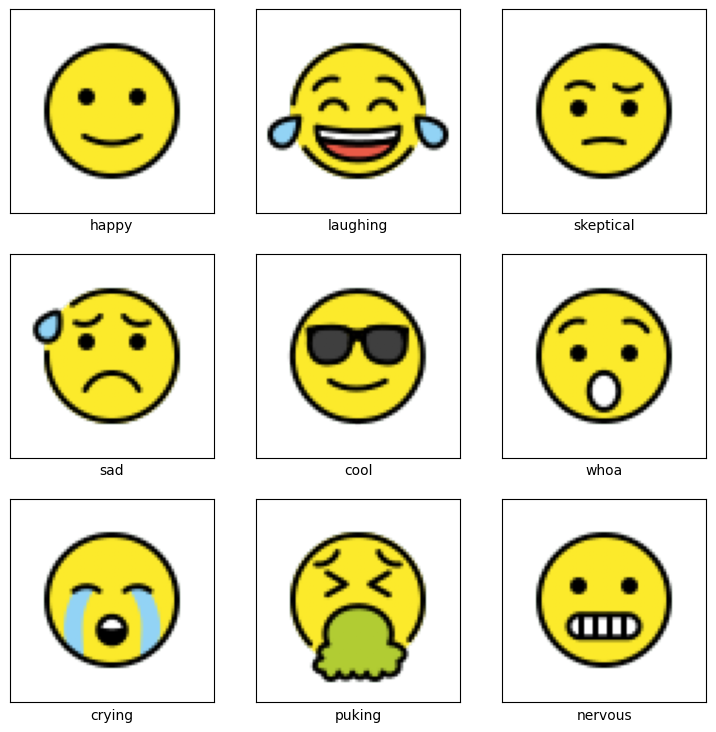

In [3]:
emojis = {
    0: {'name': 'happy', 'file': '1F642.png'},
    1: {'name': 'laughing', 'file': '1F602.png'},
    2: {'name': 'skeptical', 'file': '1F928.png'},
    3: {'name': 'sad', 'file': '1F630.png'},
    4: {'name': 'cool', 'file': '1F60E.png'},
    5: {'name': 'whoa', 'file': '1F62F.png'},
    6: {'name': 'crying', 'file': '1F62D.png'},
    7: {'name': 'puking', 'file': '1F92E.png'},
    8: {'name': 'nervous', 'file': '1F62C.png'}
}

plt.figure(figsize=(9, 9))

for i, (j, e) in enumerate(emojis.items()):
    plt.subplot(3, 3, i + 1)
    plt.imshow(plt.imread(os.path.join('emojis', e['file'])))
    plt.xlabel(e['name'])
    plt.xticks([])
    plt.yticks([])
plt.show()

## Task 2: Create Examples

In [4]:
for class_id, values in emojis.items():
    png_file = Image.open(os.path.join('emojis', values['file'])).convert('RGBA')
    png_file.load()
    new_file = Image.new("RGB", png_file.size, (255, 255, 255))
    new_file.paste(png_file, mask=png_file.split()[3])
    emojis[class_id]['image'] = new_file

In [5]:
emojis

{0: {'name': 'happy',
  'file': '1F642.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 1: {'name': 'laughing',
  'file': '1F602.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 2: {'name': 'skeptical',
  'file': '1F928.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 3: {'name': 'sad',
  'file': '1F630.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 4: {'name': 'cool',
  'file': '1F60E.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 5: {'name': 'whoa',
  'file': '1F62F.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 6: {'name': 'crying',
  'file': '1F62D.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 7: {'name': 'puking',
  'file': '1F92E.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 8: {'name': 'nervous',
  'file': '1F62C.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>}}

In [6]:
def create_example():
  class_id = np.random.randint(0, 9)
  image = np.ones((144, 144, 3)) * 255
  row = np.random.randint(0, 72)
  col = np.random.randint(0, 72)
  image[row: row + 72, col: col + 72, :] = np.array(emojis[class_id]['image'])
  return image.astype('uint8'), class_id, (row + 10) / 144, (col + 10) / 144

## Task 3: Plot Bounding Boxes

In [7]:
def plot_bounding_box(image, gt_coords, pred_coords = [], norm = False):
  if norm:
    image *= 255.
    image = image.astype('uint8')
  image = Image.fromarray(image)
  draw = ImageDraw.Draw(image)

  row, col = gt_coords
  row *= 144
  col *= 144
  draw.rectangle((col, row, col + 52, row + 52), outline = 'green', width = 3)

  if len(pred_coords) == 2:
    row, col = pred_coords
    row *= 144
    col *= 144
    draw.rectangle((col, row, col + 52, row + 52), outline = 'red', width = 3)

  return image

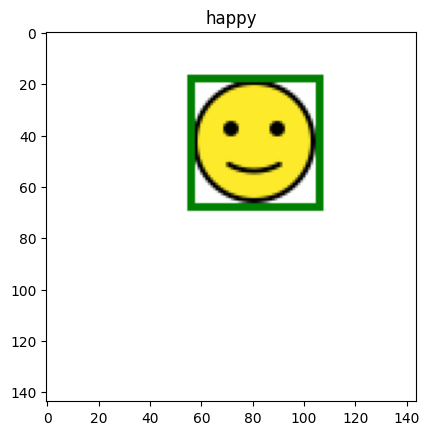

In [8]:
image, class_id, row, col = create_example()

image = plot_bounding_box(image, gt_coords = [row, col])
plt.imshow(image)
plt.title(emojis[class_id]['name'])
plt.show()

## Task 4: Data Generator

In [9]:
def data_generator(batch_size = 16):
  while True:
    x_batch = np.zeros((batch_size, 144, 144, 3), dtype='float32')
    y_batch = np.zeros((batch_size, 9), dtype='float32')
    bbox_batch = np.zeros((batch_size, 2), dtype='float32')

    for i in range(0, batch_size):
      image, class_id, row, col = create_example()
      x_batch[i] = image / 255.
      y_batch[i, class_id] = 1.0
      bbox_batch[i] = np.array([row, col])
    yield {'image': x_batch}, {'class_out': y_batch, 'box_out': bbox_batch}

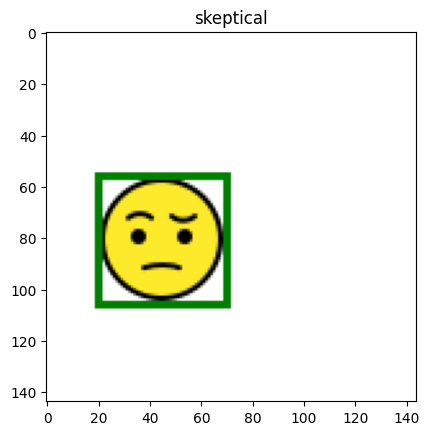

In [10]:
example, label = next(data_generator(1))
image = example['image'][0]
class_id = np.argmax(label['class_out'][0])
coords = label['box_out'][0]

image = plot_bounding_box(image, coords, norm = True)
plt.imshow(image)
plt.title(emojis[class_id]['name'])
plt.show()

## Task 5: Model

In [11]:
input_ = Input(shape = (144, 144, 3), name = 'image')

x = input_

for i in range(0, 5):
  n_filters = 2**(4 + i)
  x = Conv2D(n_filters, 3, activation = 'relu')(x)
  x = BatchNormalization()(x)
  x = MaxPool2D(2)(x)

x = Flatten()(x)
x = Dense(256, activation = 'relu')(x)

class_out = Dense(9, activation = 'softmax', name = 'class_out')(x)
box_out = Dense(2, name = 'box_out')(x)

model = tf.keras.models.Model(input_, [class_out, box_out])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 144, 144,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 142, 142,  │        448 │ image[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 142, 142,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 71, 71,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 69, 69,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 69, 69,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 34, 34,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 7, 7, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 5, 5, 256) │    295,168 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5, 5, 256) │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 2, 2, 256) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1024)      │          0 │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 659,819 (2.52 MB)

 Trainable params: 658,827 (2.51 MB)

 Non-trainable params: 992 (3.88 KB)

## Task 6: Custom Metric: IoU

In [19]:
class IoU(tf.keras.metrics.Metric):
    def __init__(self, name='iou', **kwargs):
        super(IoU, self).__init__(name=name, **kwargs)
        self.total_iou = self.add_weight(name='total_iou', initializer='zeros')
        self.num_ex = self.add_weight(name='num_ex', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        def get_box(y):
            rows, cols = y[:, 0], y[:, 1]
            rows, cols = rows * 144, cols * 144
            y1, y2 = rows, rows + 52
            x1, x2 = cols, cols + 52
            return x1, y1, x2, y2

        def get_area(x1, y1, x2, y2):
            return tf.math.maximum(0.0, x2 - x1) * tf.math.maximum(0.0, y2 - y1)

        gt_x1, gt_y1, gt_x2, gt_y2 = get_box(y_true)
        p_x1, p_y1, p_x2, p_y2 = get_box(y_pred)

        i_x1 = tf.maximum(gt_x1, p_x1)
        i_y1 = tf.maximum(gt_y1, p_y1)
        i_x2 = tf.minimum(gt_x2, p_x2)
        i_y2 = tf.minimum(gt_y2, p_y2)

        i_area = get_area(i_x1, i_y1, i_x2, i_y2)
        u_area = get_area(gt_x1, gt_y1, gt_x2, gt_y2) + get_area(p_x1, p_y1, p_x2, p_y2) - i_area

        iou = tf.math.divide_no_nan(i_area, u_area)

        self.total_iou.assign_add(tf.reduce_sum(iou))
        self.num_ex.assign_add(tf.cast(tf.shape(y_true)[0], tf.float32))

    def result(self):
        return tf.math.divide_no_nan(self.total_iou, self.num_ex)

    def reset_state(self):
        self.total_iou.assign(0.0)
        self.num_ex.assign(0.0)

## Task 7: Compile the Model

In [20]:
model.compile(
    loss={
        'class_out': 'categorical_crossentropy',
        'box_out': 'mse'
    },
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics={
        'class_out': 'accuracy',
        'box_out': IoU(name='iou')
    }
)

## Task 8: Custom Callback: Model Testing

In [14]:
def test_model(model, test_datagen):
    example, label = next(test_datagen)
    x = example['image']
    y = label['class_out']
    box = label['box_out']

    pred_y, pred_box = model.predict(x)

    pred_coords = pred_box[0]
    gt_coords = box[0]
    pred_class = np.argmax(pred_y[0])
    image = x[0]

    gt = emojis[np.argmax(y[0])]['name']
    pred_class_name = emojis[pred_class]['name']

    image = plot_bounding_box(image, gt_coords, pred_coords, norm=True)
    color = 'green' if gt == pred_class_name else 'red'

    plt.imshow(image)
    plt.xlabel(f'Pred: {pred_class_name}', color=color)
    plt.ylabel(f'GT: {gt}', color=color)
    plt.xticks([])
    plt.yticks([])

In [15]:
def test(model):
    test_datagen = data_generator(1)

    plt.figure(figsize=(16, 4))

    for i in range(0, 6):
        plt.subplot(1, 6, i + 1)
        test_model(model, test_datagen)
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


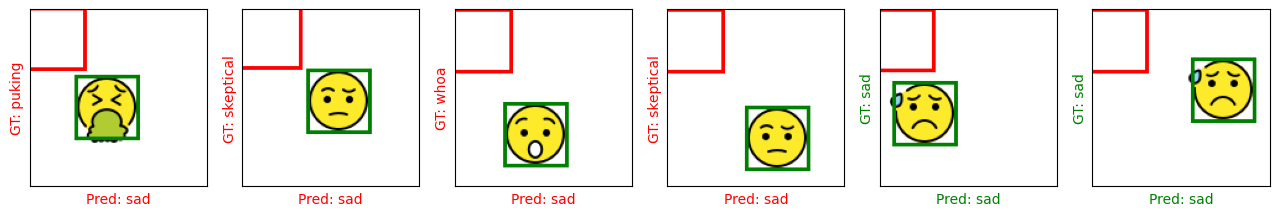

In [16]:
test(model)

In [17]:
class ShowTestImages(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs = None):
    test(self.model)

## Task 9: Model Training

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: image
Received: inputs=['Tensor(shape=(16, 144, 144, 3))']
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


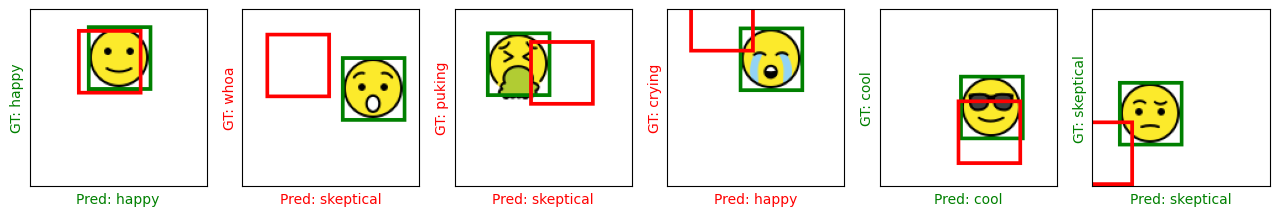

500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - box_out_iou: 0.2935 - box_out_loss: 0.0488 - class_out_accuracy: 0.9869 - class_out_loss: 0.0512 - loss: 0.1000 - learning_rate: 0.0010
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


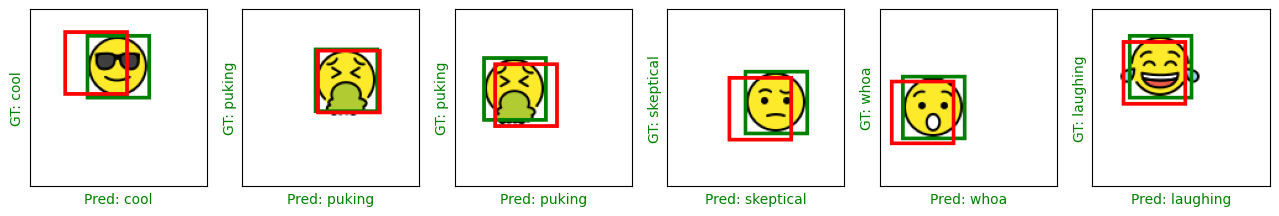

500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - box_out_iou: 0.5963 - box_out_loss: 0.0050 - class_out_accuracy: 1.0000 - class_out_loss: 0.0012 - loss: 0.0062 - learning_rate: 0.0010
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


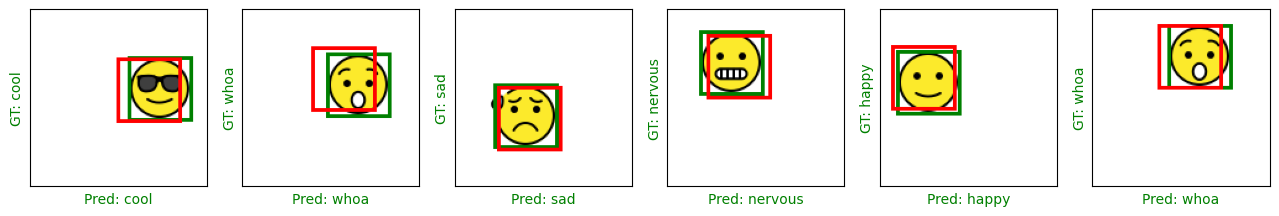

500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - box_out_iou: 0.6813 - box_out_loss: 0.0024 - class_out_accuracy: 1.0000 - class_out_loss: 4.8826e-04 - loss: 0.0029 - learning_rate: 0.0010
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


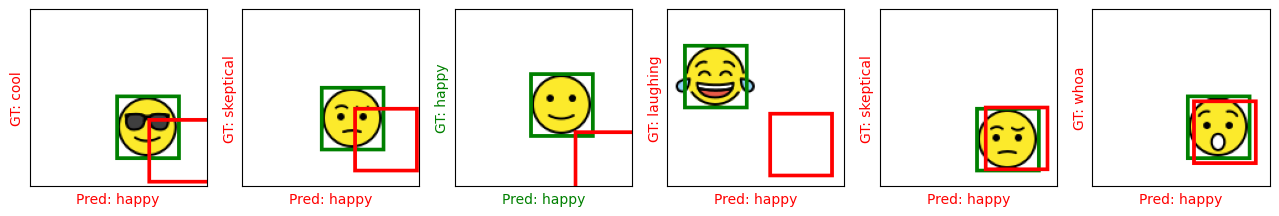

500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - box_out_iou: 0.4907 - box_out_loss: 0.0198 - class_out_accuracy: 0.9847 - class_out_loss: 0.0606 - loss: 0.0804 - learning_rate: 0.0010
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


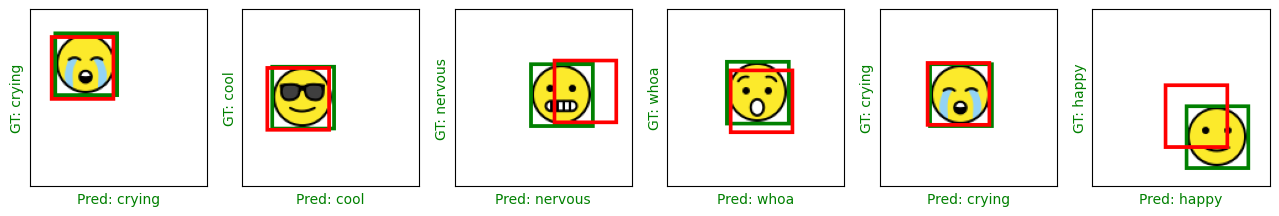

500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - box_out_iou: 0.6784 - box_out_loss: 0.0026 - class_out_accuracy: 1.0000 - class_out_loss: 0.0014 - loss: 0.0040 - learning_rate: 2.0000e-04
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


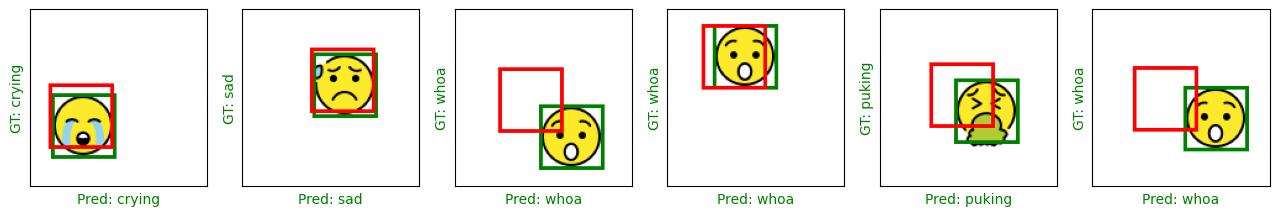

500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - box_out_iou: 0.7303 - box_out_loss: 0.0016 - class_out_accuracy: 0.9996 - class_out_loss: 0.0011 - loss: 0.0027 - learning_rate: 2.0000e-04
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


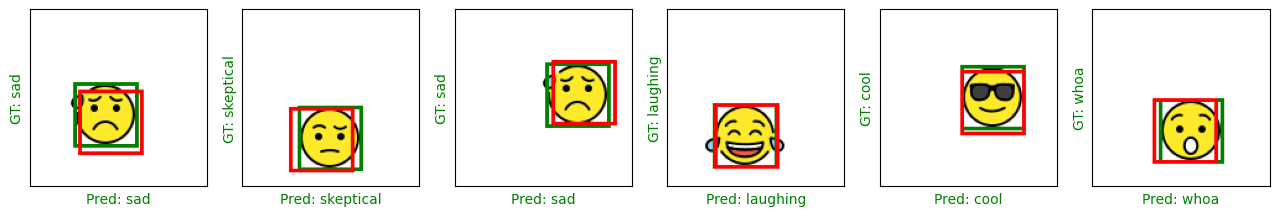

500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - box_out_iou: 0.7579 - box_out_loss: 0.0012 - class_out_accuracy: 1.0000 - class_out_loss: 3.6098e-04 - loss: 0.0016 - learning_rate: 2.0000e-04
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


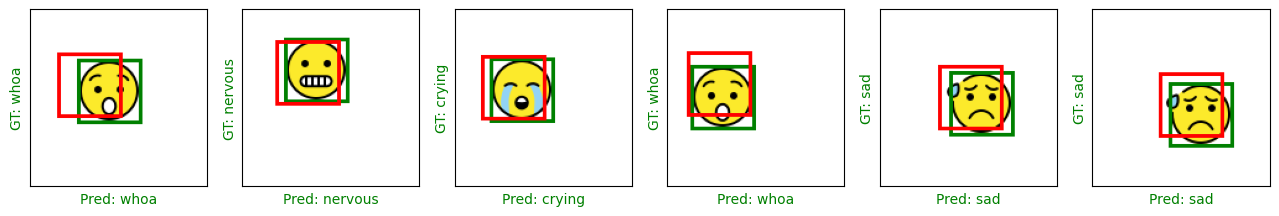

500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - box_out_iou: 0.7748 - box_out_loss: 0.0010 - class_out_accuracy: 0.9998 - class_out_loss: 0.0019 - loss: 0.0029 - learning_rate: 2.0000e-04
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


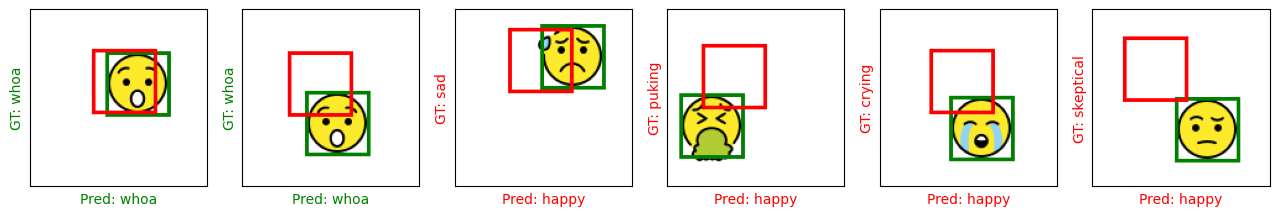

500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - box_out_iou: 0.7811 - box_out_loss: 9.5387e-04 - class_out_accuracy: 0.9999 - class_out_loss: 4.0905e-04 - loss: 0.0014 - learning_rate: 2.0000e-04
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


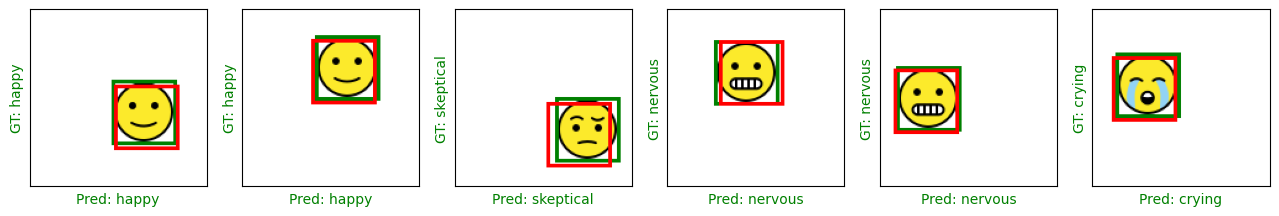

500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - box_out_iou: 0.8114 - box_out_loss: 6.7438e-04 - class_out_accuracy: 1.0000 - class_out_loss: 3.0372e-04 - loss: 9.7810e-04 - learning_rate: 4.0000e-05
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


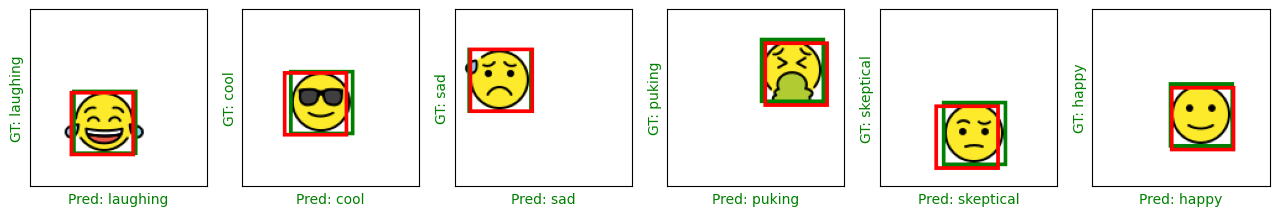

500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - box_out_iou: 0.8137 - box_out_loss: 6.6067e-04 - class_out_accuracy: 1.0000 - class_out_loss: 1.0081e-04 - loss: 7.6148e-04 - learning_rate: 4.0000e-05
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


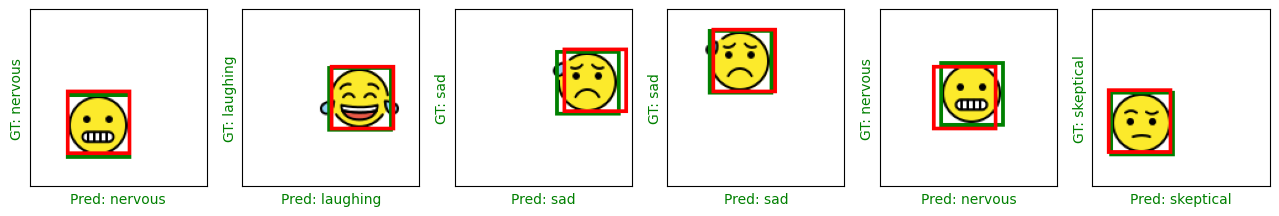

500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - box_out_iou: 0.8165 - box_out_loss: 6.2452e-04 - class_out_accuracy: 1.0000 - class_out_loss: 2.1284e-04 - loss: 8.3735e-04 - learning_rate: 4.0000e-05
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


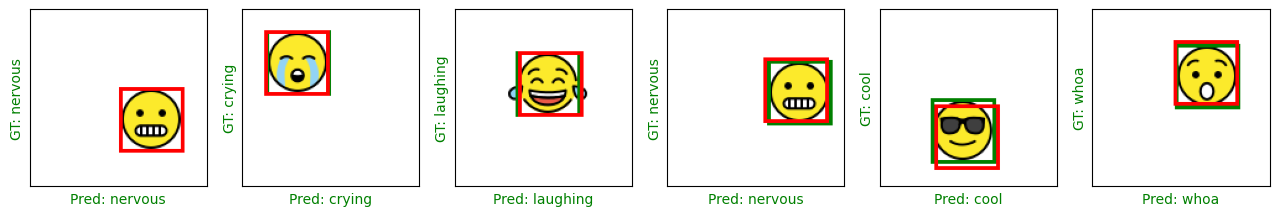

500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - box_out_iou: 0.8225 - box_out_loss: 5.9011e-04 - class_out_accuracy: 1.0000 - class_out_loss: 7.3174e-05 - loss: 6.6329e-04 - learning_rate: 4.0000e-05
Epoch 14/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


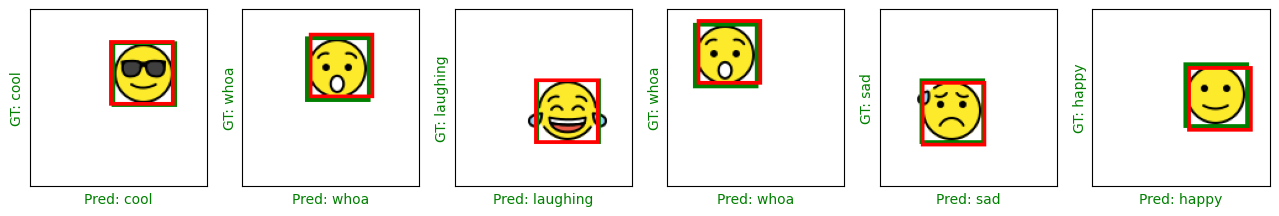

500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - box_out_iou: 0.8267 - box_out_loss: 5.5064e-04 - class_out_accuracy: 1.0000 - class_out_loss: 8.7585e-05 - loss: 6.3823e-04 - learning_rate: 4.0000e-05
Epoch 15/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


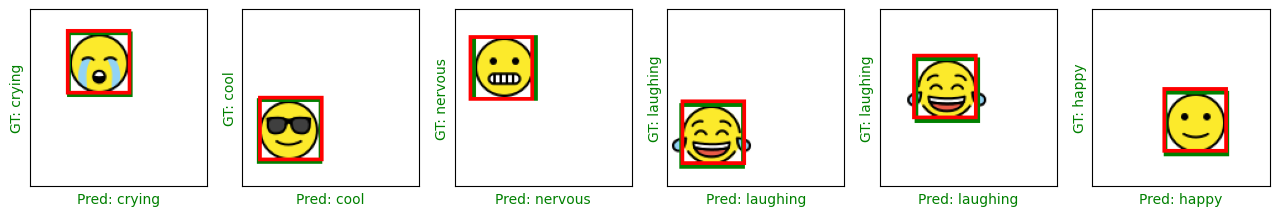

500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - box_out_iou: 0.8349 - box_out_loss: 5.0482e-04 - class_out_accuracy: 1.0000 - class_out_loss: 7.6950e-05 - loss: 5.8177e-04 - learning_rate: 8.0000e-06
Epoch 16/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


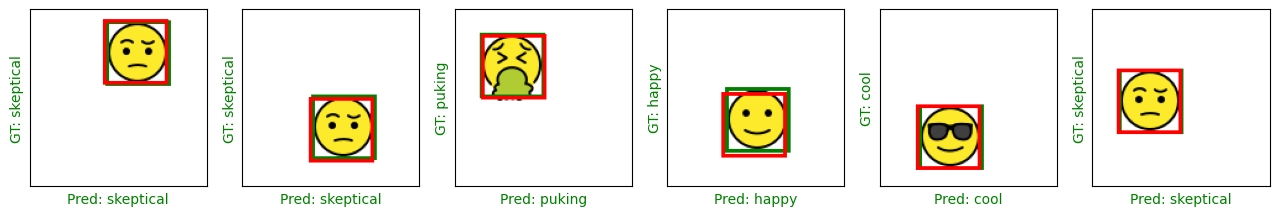

500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - box_out_iou: 0.8370 - box_out_loss: 4.8408e-04 - class_out_accuracy: 1.0000 - class_out_loss: 8.1099e-05 - loss: 5.6518e-04 - learning_rate: 8.0000e-06
Epoch 17/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


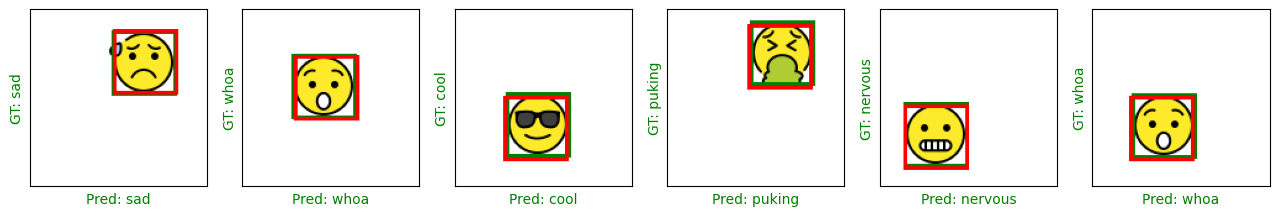

500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - box_out_iou: 0.8377 - box_out_loss: 4.7949e-04 - class_out_accuracy: 0.9999 - class_out_loss: 2.4469e-04 - loss: 7.2418e-04 - learning_rate: 8.0000e-06
Epoch 18/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


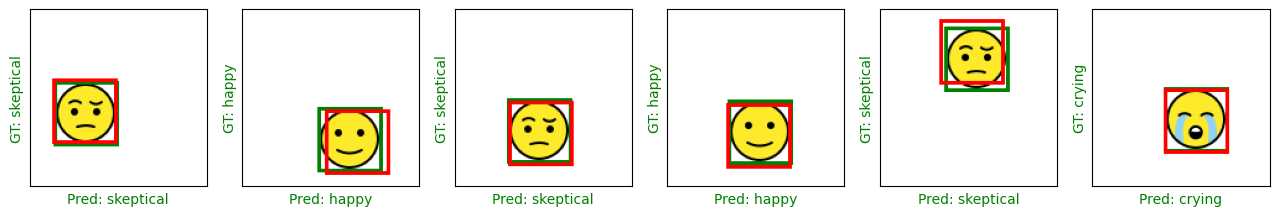

500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - box_out_iou: 0.8390 - box_out_loss: 4.7517e-04 - class_out_accuracy: 1.0000 - class_out_loss: 1.0142e-04 - loss: 5.7659e-04 - learning_rate: 8.0000e-06
Epoch 19/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


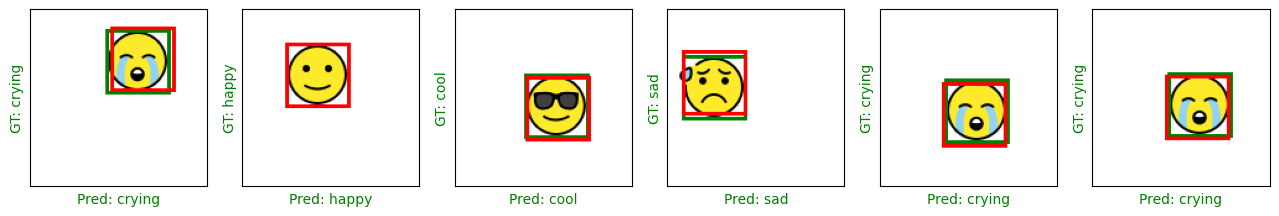

500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - box_out_iou: 0.8435 - box_out_loss: 4.4420e-04 - class_out_accuracy: 1.0000 - class_out_loss: 7.0167e-05 - loss: 5.1436e-04 - learning_rate: 8.0000e-06
Epoch 20/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


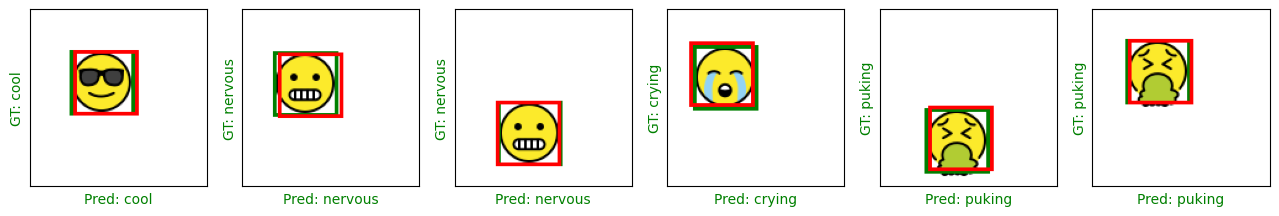

500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - box_out_iou: 0.8434 - box_out_loss: 4.4845e-04 - class_out_accuracy: 1.0000 - class_out_loss: 9.3400e-05 - loss: 5.4185e-04 - learning_rate: 1.6000e-06
Epoch 21/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


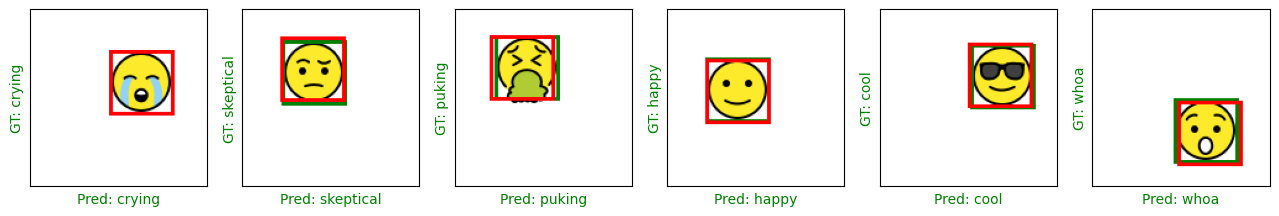

500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - box_out_iou: 0.8439 - box_out_loss: 4.3752e-04 - class_out_accuracy: 1.0000 - class_out_loss: 4.3552e-05 - loss: 4.8107e-04 - learning_rate: 1.6000e-06
Epoch 22/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


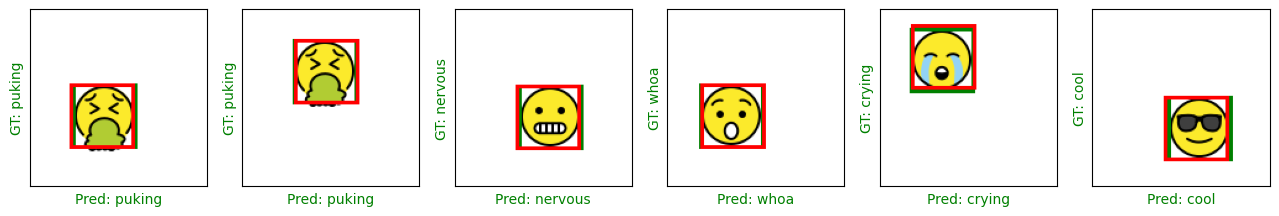

500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - box_out_iou: 0.8458 - box_out_loss: 4.2925e-04 - class_out_accuracy: 1.0000 - class_out_loss: 4.9583e-05 - loss: 4.7883e-04 - learning_rate: 1.6000e-06
Epoch 23/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


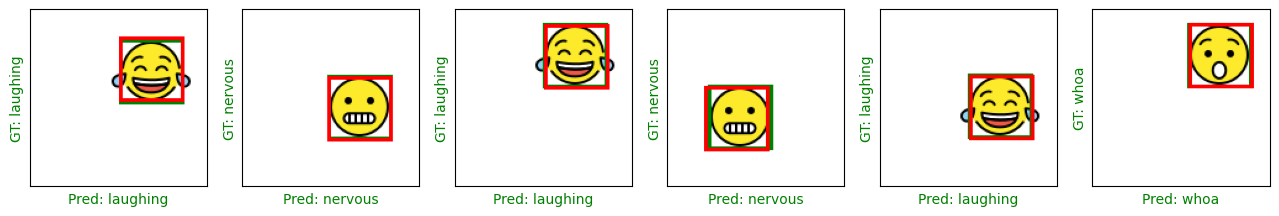

500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - box_out_iou: 0.8447 - box_out_loss: 4.3863e-04 - class_out_accuracy: 1.0000 - class_out_loss: 7.1370e-05 - loss: 5.1000e-04 - learning_rate: 1.6000e-06
Epoch 24/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


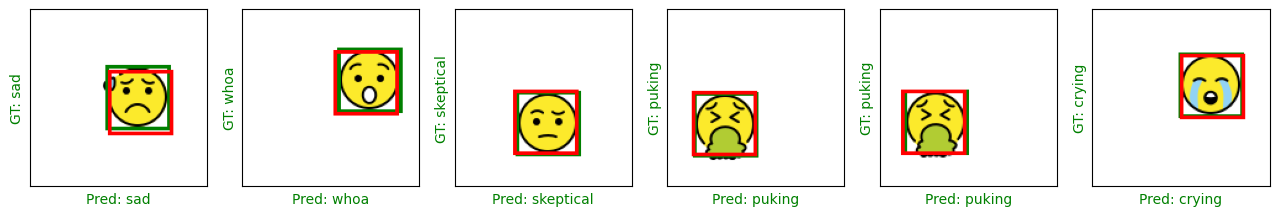

500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - box_out_iou: 0.8436 - box_out_loss: 4.3991e-04 - class_out_accuracy: 1.0000 - class_out_loss: 6.9117e-05 - loss: 5.0903e-04 - learning_rate: 1.6000e-06
Epoch 25/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


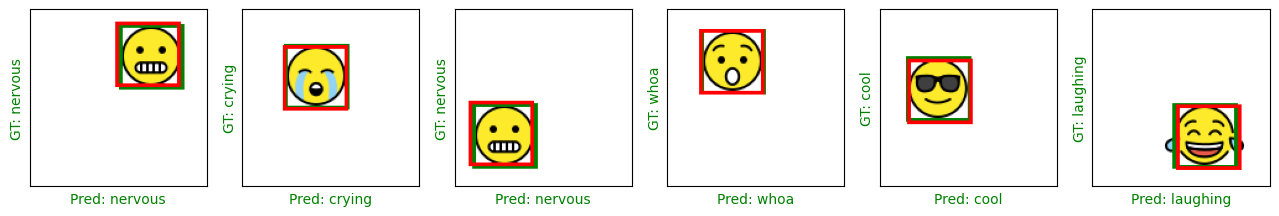

500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - box_out_iou: 0.8468 - box_out_loss: 4.2187e-04 - class_out_accuracy: 1.0000 - class_out_loss: 6.0720e-05 - loss: 4.8259e-04 - learning_rate: 3.2000e-07
Epoch 26/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


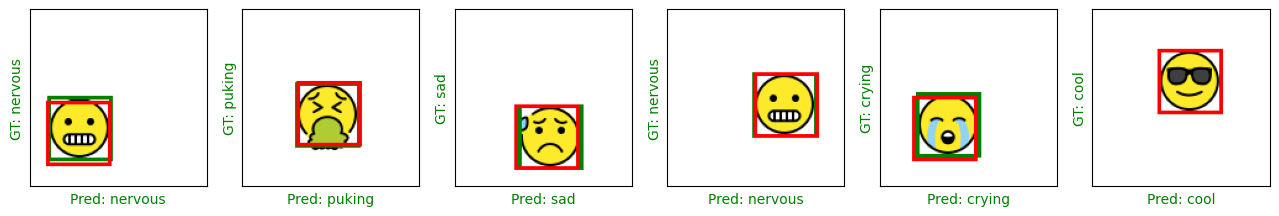

500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - box_out_iou: 0.8460 - box_out_loss: 4.2908e-04 - class_out_accuracy: 1.0000 - class_out_loss: 6.7491e-05 - loss: 4.9657e-04 - learning_rate: 3.2000e-07
Epoch 27/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


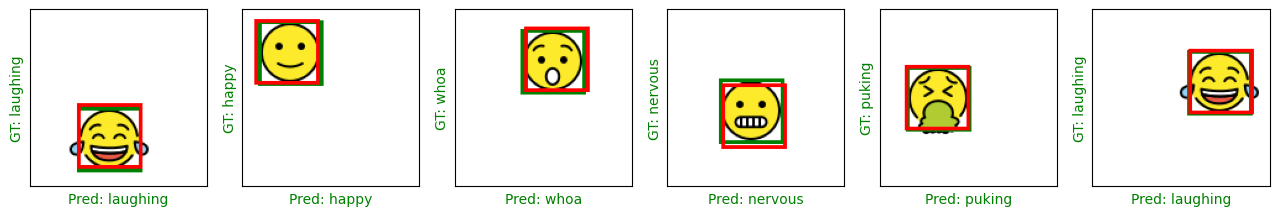

500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - box_out_iou: 0.8454 - box_out_loss: 4.2976e-04 - class_out_accuracy: 1.0000 - class_out_loss: 7.1277e-05 - loss: 5.0104e-04 - learning_rate: 3.2000e-07
Epoch 28/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


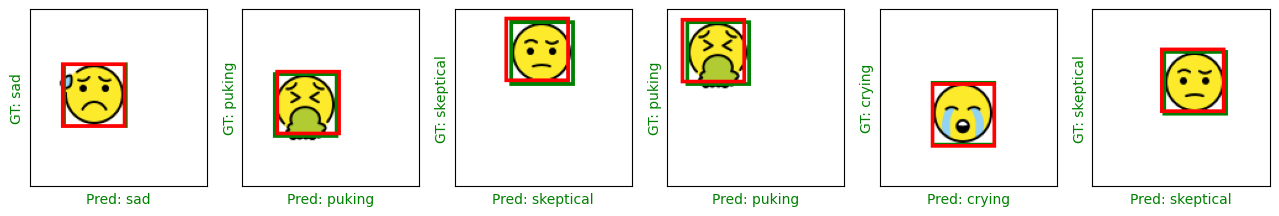

500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - box_out_iou: 0.8453 - box_out_loss: 4.3257e-04 - class_out_accuracy: 1.0000 - class_out_loss: 5.6537e-05 - loss: 4.8911e-04 - learning_rate: 3.2000e-07


In [21]:
def lr_schedule(epoch, lr):
    if (epoch + 1) % 5 == 0:
        lr *= 0.2
    return max(lr, 3e-7)

dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(batch_size=16),
    output_signature=(
        {'image': tf.TensorSpec(shape=(16, 144, 144, 3), dtype=tf.float32)},
        {
            'class_out': tf.TensorSpec(shape=(16, 9), dtype=tf.float32),
            'box_out': tf.TensorSpec(shape=(16, 2), dtype=tf.float32)
        }
    )
).repeat()

_ = model.fit(
    dataset,
    epochs=50,
    steps_per_epoch=500,
    callbacks=[
        ShowTestImages(),
        tf.keras.callbacks.EarlyStopping(monitor='box_out_iou', patience=3, mode='max'),
        tf.keras.callbacks.LearningRateScheduler(lr_schedule)
    ]
)